In [1]:
import numpy, pandas, matplotlib, sklearn
print("Todo listo")

Todo listo


# PCA aplicado al conjunto de datos MNIST

En este notebook se transforma cada imagen de 28x28 píxeles en un vector de 784 variables (una imagen por fila), se estandarizan los datos, se aplica PCA y se grafica el resultado en 2D.

## 1. Importar librerías

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request
import os

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## 2. Cargar el conjunto de datos MNIST

MNIST contiene 70,000 imágenes de dígitos escritos a mano (del 0 al 9). Cada imagen mide 28x28 píxeles en escala de grises, con valores de 0 (negro) a 255 (blanco). Vienen separadas en 60,000 de entrenamiento y 10,000 de prueba; aquí las unimos en un solo conjunto.

In [3]:
url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
archivo = "mnist.npz"

# Descargamos el archivo 
if not os.path.exists(archivo):
    urllib.request.urlretrieve(url, archivo)

# Cargamos las imágenes y sus etiquetas
with np.load(archivo) as datos:
    x_train, y_train = datos["x_train"], datos["y_train"]
    x_test, y_test = datos["x_test"], datos["y_test"]

# Unimos entrenamiento y prueba
X_imagenes = np.concatenate([x_train, x_test])
y = np.concatenate([y_train, y_test])

print("Forma de las imágenes:", X_imagenes.shape)
print("Forma de las etiquetas:", y.shape)

Forma de las imágenes: (70000, 28, 28)
Forma de las etiquetas: (70000,)


## 3. Explorar los datos

Revisamos cómo es una imagen, el rango de sus valores y visualizamos algunos ejemplos con su etiqueta.

In [4]:
print("Forma de una sola imagen:", X_imagenes[0].shape)
print("Valor mínimo:", X_imagenes.min())
print("Valor máximo:", X_imagenes.max())
print("Etiqueta de la primera imagen:", y[0])

Forma de una sola imagen: (28, 28)
Valor mínimo: 0
Valor máximo: 255
Etiqueta de la primera imagen: 5


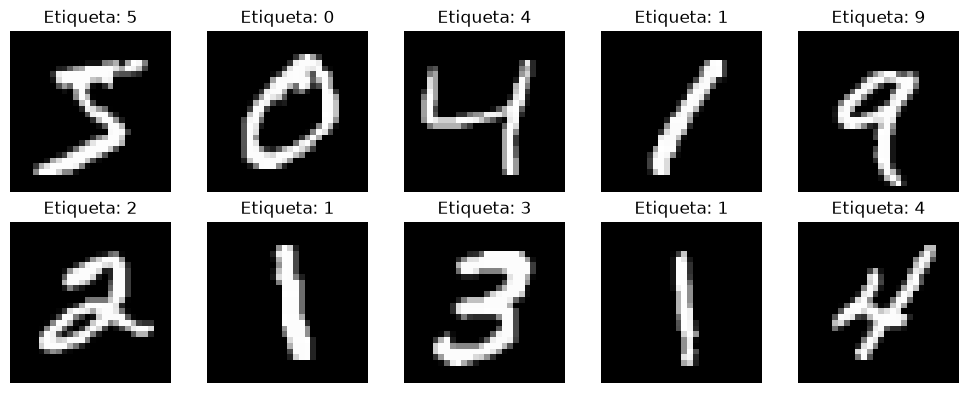

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_imagenes[i], cmap="gray")
    ax.set_title(f"Etiqueta: {y[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

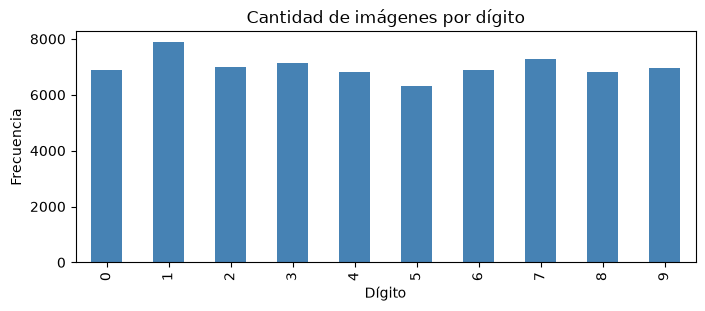

In [6]:
pd.Series(y).value_counts().sort_index().plot(kind="bar", figsize=(8, 3), color="steelblue")
plt.title("Cantidad de imágenes por dígito")
plt.xlabel("Dígito")
plt.ylabel("Frecuencia")
plt.show()

## 4. Transformar las imágenes de 28x28 a vectores de 784 variables

Cada imagen de 28x28 se aplana en un vector de 28 × 28 = 784 valores. El resultado es una matriz donde cada fila es una imagen y cada columna es un píxel.

In [7]:
n_imagenes = X_imagenes.shape[0]
X = X_imagenes.reshape(n_imagenes, 28 * 28)

print("Forma original:", X_imagenes.shape)
print("Forma nueva:   ", X.shape)

Forma original: (70000, 28, 28)
Forma nueva:    (70000, 784)


In [8]:
columnas = [f"pixel_{i}" for i in range(784)]
df = pd.DataFrame(X, columns=columnas)
df["etiqueta"] = y

df.head()

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783,etiqueta
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9


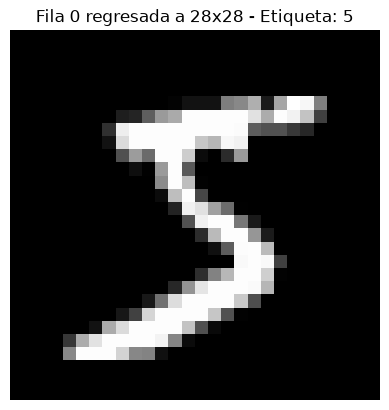

In [9]:
plt.imshow(X[0].reshape(28, 28), cmap="gray")
plt.title(f"Fila 0 regresada a 28x28 - Etiqueta: {y[0]}")
plt.axis("off")
plt.show()

## 5. Estandarización

Se estandariza cada variable (píxel) para que tenga media 0 y desviación estándar 1, usando la fórmula:

$$z = \frac{x - \mu}{\sigma}$$

Esto es necesario porque PCA es sensible a la escala de las variables.

In [10]:
X = X.astype(np.float64)

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

print("Forma:", X_std.shape)
print("Media general:", X_std.mean().round(4))
print("Desviación estándar general:", X_std.std().round(4))

Forma: (70000, 784)
Media general: -0.0
Desviación estándar general: 0.9576


In [11]:
pixeles_constantes = (X.std(axis=0) == 0).sum()
print("Píxeles que siempre valen 0 (sin variación):", pixeles_constantes)

Píxeles que siempre valen 0 (sin variación): 65


## 6. Aplicar PCA

Se reducen las 784 variables estandarizadas a 2 componentes principales. Cada componente es una combinación lineal de los píxeles, elegida para capturar la mayor varianza posible de los datos.

In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

print("Forma antes de PCA:  ", X_std.shape)
print("Forma después de PCA:", X_pca.shape)
print("Varianza explicada por PC1:", round(pca.explained_variance_ratio_[0] * 100, 2), "%")
print("Varianza explicada por PC2:", round(pca.explained_variance_ratio_[1] * 100, 2), "%")
print("Varianza explicada total:  ", round(pca.explained_variance_ratio_.sum() * 100, 2), "%")

Forma antes de PCA:   (70000, 784)
Forma después de PCA: (70000, 2)
Varianza explicada por PC1: 5.64 %
Varianza explicada por PC2: 4.04 %
Varianza explicada total:   9.68 %


In [13]:
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["etiqueta"] = y

df_pca.head()

,PC1,PC2,etiqueta
0,-0.891720,-4.929711,5
1,8.813530,-7.517560,0
2,2.204835,9.824461,4
3,-6.534627,-4.029669,1
4,-5.251618,3.278848,9


## 7. Graficar en 2D

Cada punto representa una imagen, ubicada según los valores de PC1 y PC2, y coloreada según el dígito que representa.

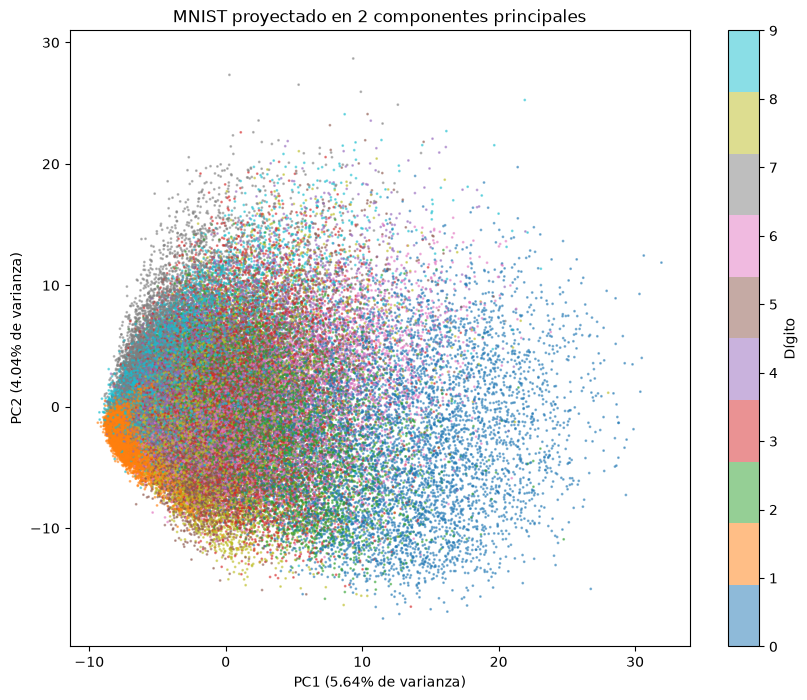

In [14]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(df_pca["PC1"], df_pca["PC2"],
                      c=df_pca["etiqueta"], cmap="tab10",
                      s=1, alpha=0.5)

plt.colorbar(scatter, ticks=range(10), label="Dígito")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% de varianza)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% de varianza)")
plt.title("MNIST proyectado en 2 componentes principales")
plt.show()

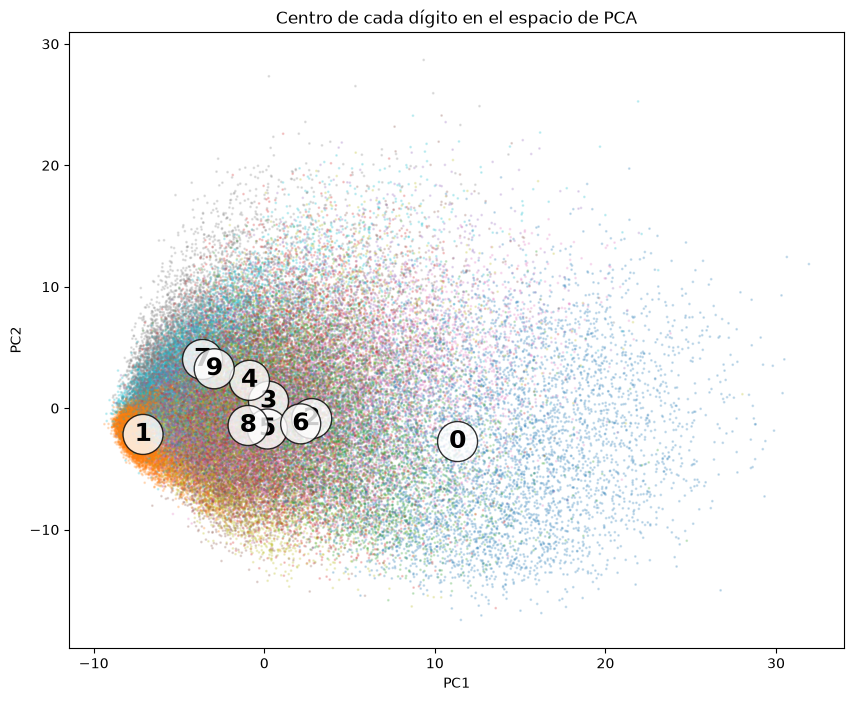

In [15]:
centroides = df_pca.groupby("etiqueta")[["PC1", "PC2"]].mean()

plt.figure(figsize=(10, 8))
plt.scatter(df_pca["PC1"], df_pca["PC2"],
            c=df_pca["etiqueta"], cmap="tab10", s=1, alpha=0.2)

for digito, fila in centroides.iterrows():
    plt.text(fila["PC1"], fila["PC2"], str(digito),
             fontsize=18, weight="bold", ha="center", va="center",
             bbox=dict(facecolor="white", alpha=0.8, boxstyle="circle"))

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Centro de cada dígito en el espacio de PCA")
plt.show()

## 8. Conclusiones

- Cada imagen de 28x28 píxeles se transformó en un vector de 784 variables, obteniendo una matriz de 70,000 filas (imágenes) por 784 columnas (píxeles).
- Se estandarizaron los datos para que todos los píxeles tuvieran media 0 y desviación estándar 1. Se encontraron 65 píxeles de los bordes que valen 0 en todas las imágenes, por lo que no aportan información.
- Con PCA se redujeron las 784 variables a 2 componentes principales. PC1 explica el 5.64% de la varianza y PC2 el 4.04%, sumando 9.68% en total. Esto significa que en 2D se conserva menos del 10% de la información original, lo que explica el traslape entre la mayoría de los dígitos.
- En la gráfica, el dígito 1 forma un grupo compacto a la izquierda y el 0 queda disperso a la derecha. Esto sugiere que PC1 está relacionada con la cantidad de píxeles encendidos: el 1 usa muy pocos y el 0 usa muchos.
- Los dígitos 7, 9 y 4 aparecen juntos porque tienen formas similares, al igual que el 3, 5 y 8, que se encuentran encimados en el centro.
- PCA permite visualizar un conjunto de datos de 784 dimensiones en solo 2, y aunque no separa todos los dígitos, sí muestra patrones claros en su estructura. Para lograr una mejor separación se podrían usar más componentes o métodos no lineales como t-SNE o UMAP.